In [1]:
import pandas as pd

In [2]:
eggs = {}

In [3]:
eggs["green_random"] = pd.DataFrame(
    [[0,0,0,1,0],
     [0,0,0,0,0]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [4]:
eggs["purple_random"] = pd.DataFrame(
    [[1,2,1,0,0],
     [0,0,2,0,0]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [5]:
eggs["pink_random"] = pd.DataFrame(
    [[0,1,0,0,1],
     [1,1,0,0,2]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [6]:
eggs["red_random"] = pd.DataFrame(
    [[1,1,0,0,1],
     [1,0,1,0,0]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [7]:
eggs["yellow_random"] = pd.DataFrame(
    [[1,0,1,0,0],
     [0,2,0,0,1]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [8]:
eggs["green_toddler"] = pd.DataFrame(
    [[0,0,0,0,0],
     [1,0,0,1,0]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [9]:
eggs["purple_toddler"] = pd.DataFrame(
    [[2,0,0,0,0],
     [0,0,0,0,0]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [10]:
eggs["pink_toddler"] = pd.DataFrame(
    [[0,0,0,0,0],
     [0,0,1,0,0]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [11]:
eggs["red_toddler"] = pd.DataFrame(
    [[0,0,0,0,0],
     [0,1,1,0,0]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [12]:
eggs["yellow_toddler"] = pd.DataFrame(
    [[0,0,0,0,0],
     [0,0,0,0,0]],
    columns=["red","yellow","green", 'purple', 'pink'],
    index=["circle","square"]
)

In [13]:
records = []

for egg_name, mat in eggs.items():
    source = "random" if "random" in egg_name else "toddler"
    
    for color in mat.index:
        for shape in mat.columns:
            count = mat.loc[color, shape]
            records.append({
                "egg": egg_name,
                "source": source,
                "color": color,
                "shape": shape,
                "count": count
            })

df = pd.DataFrame(records)

In [14]:
df

,egg,source,color,shape,count
0,green_random,random,circle,red,0
1,green_random,random,circle,yellow,0
2,green_random,random,circle,green,0
3,green_random,random,circle,purple,1
4,green_random,random,circle,pink,0
...,...,...,...,...,...
95,yellow_toddler,toddler,square,red,0
96,yellow_toddler,toddler,square,yellow,0
97,yellow_toddler,toddler,square,green,0
98,yellow_toddler,toddler,square,purple,0


In [15]:
from scipy.stats import chi2_contingency

# def chi_test(sub):
#     table = sub.pivot_table(index="color", columns="shape", values="count", aggfunc="sum", fill_value=0)
#     chi2, p, _, _ = chi2_contingency(table)
#     return p

def chi_test(sub):
    table = sub.pivot_table(
        index="color", columns="shape",
        values="count", aggfunc="sum", fill_value=0
    )
    
    table = table + 1e-6  # smoothing
    
    chi2, p, _, _ = chi2_contingency(table)
    return p
print("Random p:", chi_test(df[df.source=="random"]))
print("Toddler p:", chi_test(df[df.source=="toddler"]))

Random p: 0.7902461607999274
Toddler p: 0.44329748013017445


In [16]:
from scipy.stats import entropy

def matrix_entropy(mat):
    vals = mat.values.flatten()
    probs = vals / vals.sum() if vals.sum() > 0 else vals
    return entropy(probs)

entropy_results = {
    egg: matrix_entropy(mat)
    for egg, mat in eggs.items()
}

/home/simonhans/anaconda3/lib/python3.7/site-packages/scipy/stats/_distn_infrastructure.py:2664: RuntimeWarning: invalid value encountered in true_divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)


In [17]:
agg = df.groupby(["source","color","shape"])["count"].sum().reset_index()

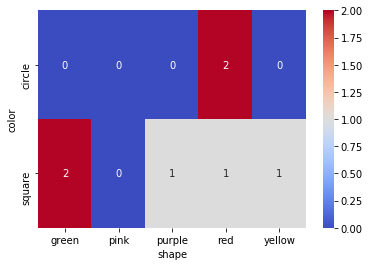

In [18]:
import seaborn as sns

sns.heatmap(
    agg[agg.source=="toddler"].pivot("color","shape","count"),
    annot=True, cmap="coolwarm"
)

In [19]:
egg_counts = df.groupby(["source","egg"])["count"].sum().reset_index()

egg_counts.groupby("source")["count"].agg(["mean","var"])

,mean,var
source,,
random,4.6,4.3
toddler,1.4,0.8


In [20]:
from scipy.stats import entropy

def get_dist(sub):
    vals = sub.groupby(["color","shape"])["count"].sum()
    probs = vals / vals.sum()
    return probs

p_random = get_dist(df[df.source=="random"])
p_toddler = get_dist(df[df.source=="toddler"])
epsilon = 1e-6

p_random = p_random + epsilon
p_toddler = p_toddler + epsilon

p_random = p_random / p_random.sum()
p_toddler = p_toddler / p_toddler.sum()

kl = entropy(p_toddler, p_random)
# align indices
p_toddler = p_toddler.reindex(p_random.index, fill_value=0)

kl = entropy(p_toddler, p_random)
print("KL divergence:", kl)

KL divergence: 2.2275730603496076


In [21]:
def sparsity(mat):
    total = mat.size
    zeros = (mat == 0).sum().sum()
    return zeros / total

sparsity_results = {
    egg: sparsity(mat)
    for egg, mat in eggs.items()
}

In [22]:
df["is_zero"] = df["count"] == 0

sparsity_by_source = df.groupby("source")["is_zero"].mean()
print(sparsity_by_source)

source
random     0.62
toddler    0.88
Name: is_zero, dtype: float64


In [23]:
support = df[df["count"] > 0].groupby("source").size()
print(support)

source
random     19
toddler     6
dtype: int64


In [24]:
total_possible = df.groupby(["color","shape"]).ngroups

support_ratio = support / total_possible
print(support_ratio)

source
random     1.9
toddler    0.6
dtype: float64


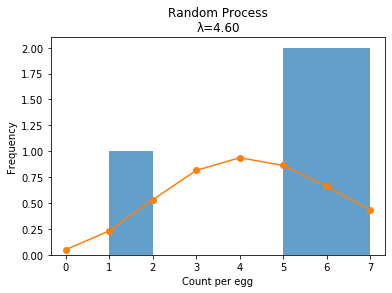

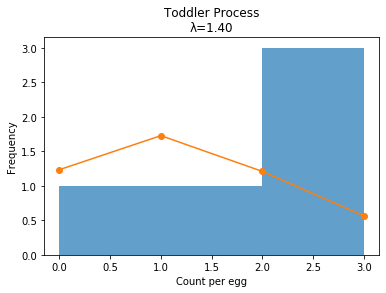

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# counts per egg
egg_counts = df.groupby(["source","egg"])["count"].sum().reset_index()

rand_counts = egg_counts[egg_counts.source=="random"]["count"]
tod_counts = egg_counts[egg_counts.source=="toddler"]["count"]

def plot_poisson_fit(counts, title):
    lam = counts.mean()
    x = np.arange(0, counts.max() + 2)

    plt.figure()
    
    # histogram
    plt.hist(counts, bins=x, alpha=0.7)
    
    # poisson expected
    expected = poisson.pmf(x, lam) * len(counts)
    plt.plot(x, expected, 'o-')
    
    plt.title(f"{title}\nλ={lam:.2f}")
    plt.xlabel("Count per egg")
    plt.ylabel("Frequency")
    plt.show()

plot_poisson_fit(rand_counts, "Random Process")
plot_poisson_fit(tod_counts, "Toddler Process")

/home/simonhans/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


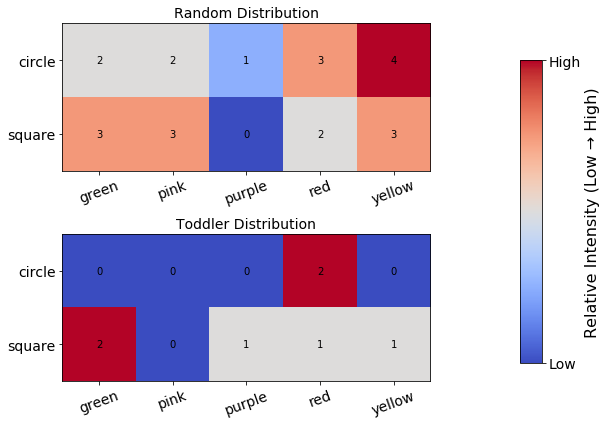

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def get_matrix(source):
    sub = df[df.source == source]
    return sub.pivot_table(
        index="color",
        columns="shape",
        values="count",
        aggfunc="sum",
        fill_value=0
    )

mat_random = get_matrix("random")
mat_toddler = get_matrix("toddler")

# align axes
colors = sorted(set(mat_random.index).union(mat_toddler.index))
shapes = sorted(set(mat_random.columns).union(mat_toddler.columns))

mat_random = mat_random.reindex(index=colors, columns=shapes, fill_value=0)
mat_toddler = mat_toddler.reindex(index=colors, columns=shapes, fill_value=0)

# 👇 reserve space on the right
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plt.subplots_adjust(right=0.85)  # shrink plots to make room

# plots (independent scaling)
im1 = axes[0].imshow(mat_random.values, cmap = 'coolwarm')
im2 = axes[1].imshow(mat_toddler.values, cmap = 'coolwarm')

for ax, mat, title in zip(
    axes,
    [mat_random, mat_toddler],
    ["Random Distribution", "Toddler Distribution"]
):
    ax.set_title(title, fontsize = 14)
    ax.set_xticks(range(len(shapes)))
    ax.set_yticks(range(len(colors)))
    ax.set_xticklabels(shapes, fontsize = 14, rotation = 20)
    ax.set_yticklabels(colors, fontsize = 14)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, mat.values[i, j],
                    ha="center", va="center")

# 👇 create a dedicated colorbar axis OUTSIDE
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])  
# [left, bottom, width, height]

# abstract color scale
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap=im1.cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Relative Intensity (Low → High)", fontsize = 16)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Low", "High"])
cbar.ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig('poisson_eggs.png')
plt.show()

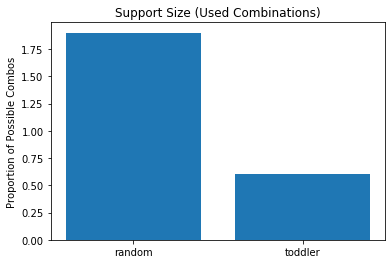

In [31]:
# count used combinations
used = df[df["count"] > 0].groupby("source").size()

# total possible combos
total = df.groupby(["color","shape"]).ngroups

support_ratio = used / total

plt.figure()
plt.bar(support_ratio.index, support_ratio.values)
plt.title("Support Size (Used Combinations)")
plt.ylabel("Proportion of Possible Combos")
plt.show()

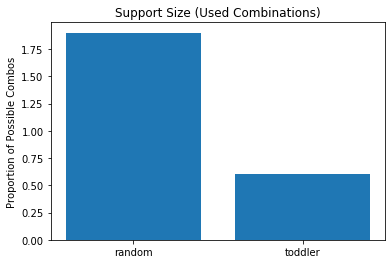

In [32]:
# count used combinations
used = df[df["count"] > 0].groupby("source").size()

# total possible combos
total = df.groupby(["color","shape"]).ngroups

support_ratio = used / total

plt.figure()
plt.bar(support_ratio.index, support_ratio.values)
plt.title("Support Size (Used Combinations)")
plt.ylabel("Proportion of Possible Combos")
plt.show()